# Implementing Foundational ML Algorithms from scratch


----


## **PCA - Principal Component Analysis**

#### Introduction

Principal Component Analysis (PCA) is a classic technique (Karl Pearson, 1901) that applies an orthogonal linear transform to convert possibly correlated variables into a new set of linearly uncorrelated variables called principal components.

Geometrically, PCA is a rotation of the data axes. Algebraically, it follows from the SVD/eigendecomposition of the (centered) covariance matrix:

- the **eigenvectors** form the rotation matrix,
- they are **ordered** by **decreasing eigenvalues**, and
- each eigenvalue equals the **variance explained** by its component.

PCA is widely used for dimensionality reduction, denoising/visualization, decorrelation, and mixture separation (e.g., in spectral analysis).

In this notebook we’ll take a geometric view: treat PCA as a rotation applied to correlated random data, as in the figure below.


<img src="./images/GaussianScatterPCA.svg.png" align="center" width="500"/>

Source: https://en.wikipedia.org/wiki/Principal_component_analysis



#### Objectives:

- Implement a Binary Classification Model using Naive Bayes:

    1- Preprocess twitter messages labeled with positive and negative sentiment.

    2- Implement the Naive Bayes algorithm from scratch.

    3- Make predictions on labeled data.

    4- Evaluate its performance using accuracy as a metric.

-----


### 1- Prepare the environment

In [2]:
import numpy as np                         
import matplotlib.pyplot as plt            
from sklearn.decomposition import PCA      
import pandas as pd                        
import math                                
import random                              

Start with two random variables $X$ and $Y$. In the simplest case:

$$
Y = k\,X \qquad (k \in \mathbb{R}).
$$

Here $Y$ is just a scaled copy of $X$, so they are **perfectly linearly correlated**:

$$
\rho_{XY} = \operatorname{corr}(X,Y) = \operatorname{sign}(k) \in \{-1,1\}.
$$

Geometrically, all samples $(x,y)$ lie exactly on the line $y=kx$ through the origin.


In [3]:
np.random.seed(23)
n = 1  # The amount of the correlation
x = np.random.uniform(1,2,1000) # Generate 1000 samples from a uniform random variable
y = x.copy() * n # Make y = n * x


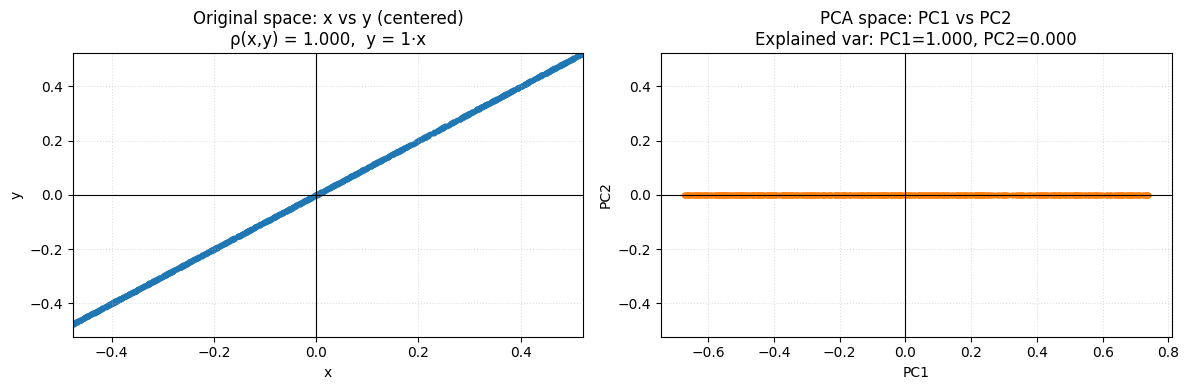

In [ ]:
# center
x = x - x.mean()
y = y - y.mean()

# dataframe
data = pd.DataFrame({'x': x, 'y': y})

# PCA (using scikit-learn)
pca = PCA(n_components=2).fit(data)
rot = pca.transform(data)                       # [N, 2]
dataPCA = pd.DataFrame(rot, columns=['PC1','PC2'])
evr = pca.explained_variance_ratio_

# y-limits based on original data (symmetric)
ymax = max(abs(y.min()), abs(y.max()))
ylims = (-ymax, ymax)

# Plots with matched y-scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

# Original space
ax1.scatter(data.x, data.y, s=10)
ax1.axhline(0, color='k', lw=.8); ax1.axvline(0, color='k', lw=.8)
ax1.set_xlim(min(x), max(x))
ax1.set_ylim(*ylims)
ax1.set_title("Original space: x vs y (centered)\n"
              f"ρ(x,y) = {np.corrcoef(x, y)[0,1]:.3f},  y = 1·x")
ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.grid(True, ls=':', alpha=.4)

# PCA space
ax2.scatter(dataPCA.PC1, dataPCA.PC2, s=10, color='tab:orange')
ax2.axhline(0, color='k', lw=.8); ax2.axvline(0, color='k', lw=.8)
ax2.set_ylim(*ylims)                             # <- key: same y-scale as left
ax2.set_title("PCA space: PC1 vs PC2\n"
              f"Explained var: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
ax2.grid(True, ls=':', alpha=.4)
ax2.ticklabel_format(axis='y', style='plain', useOffset=False)  # avoid 1e−17 display

plt.tight_layout()
plt.show()

**Conclusion**

- With $y=x$ (perfect linear correlation), all variance lies on a single line in $(x,y)$-space.  
- PCA rotates the axes so **PC1** aligns with that line and captures essentially **100%** of the variance: $\mathrm{Var}(\text{PC1}) \approx 1.0$.  
- **PC2** is orthogonal to PC1 and carries **no variance**: $\mathrm{Var}(\text{PC2}) \approx 0$, so the points collapse to a horizontal line at $0$
- This is the expected PCA behavior for collinear data: concentrate information in one component and null out the orthogonal direction.


### 2) Interpreting the fitted PCA model `pcaTr`

A fitted PCA stores two key pieces of information: an **orthonormal rotation** (the new axes) and the **variance** along those axes. Details of the rotation will be covered next.

- `pcaTr.components_` : the rotation matrix (rows = principal directions).
- `pcaTr.explained_variance_` : the variance captured by each principal component (the eigenvalues).

In [10]:
print('Eigenvectors or principal component: First row must be in the direction of [1, n]')
print(pcaTr.components_)

print()
print('Eigenvalues or explained variance')
print(pcaTr.explained_variance_)

Eigenvectors or principal component: First row must be in the direction of [1, n]
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

Eigenvalues or explained variance
[0.16695176 0.        ]


$\cos 45^\circ = 0.7071$

Rotation matrix for $\theta = 45^\circ$:
  $$
  R =
  \begin{bmatrix}
  \cos 45^\circ & \sin 45^\circ \\
  -\sin 45^\circ & \cos 45^\circ
  \end{bmatrix}.
  $$
  This is the same angle as the line $y = 1\cdot x$, PCA aligns the first axis with that direction.

For $X \sim \mathcal{U}(1,2)$ (and $Y=X$):
  $$
  \operatorname{Var}(X)=\frac{(2-1)^2}{12}=\frac{1}{12}\approx 0.08333.
  $$

Covariance matrix (centered) is
  $$
  \Sigma=
  \begin{bmatrix}
  v & v\\
  v & v
  \end{bmatrix},\quad v=\operatorname{Var}(X)=\tfrac{1}{12}.
  $$
  Its eigenvalues (explained variances) are
  $$
  \lambda_1 = 2v = \tfrac{1}{6}\approx 0.1667,\qquad
  \lambda_2 = 0.
  $$

Interpretation:
  $$
  \text{Explained variance} \approx [\,0.1667,\; 0\,],
  $$
  i.e., **all** variance lies on PC1 and PC2 carries none.


### 3) Correlated Normal Random Variables


We want a controlled 2D dataset where each variable has a chosen variance and the pair has a specific covariance. A simple way to build this is:

- First generate two **independent** normal variables with the variances we want.
- Then **mix** them with a rotation (i.e., take a linear combination).

This mixing step introduces dependence between the two coordinates, producing the desired **correlation** while keeping the individual variances under control. It’s a convenient recipe for creating data with known variance and covariance structure.

In [11]:
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms

In [12]:
# 1st variable
std1 = 1 # The desired standard deviation
x = np.random.normal(0, std1, 1000) # Get 1000 samples from x ~ N(0, std1)

# 2nd variable
std2 = 0.333 # The desired standard deviation of our second random variable     
y = np.random.normal(0, std2, 1000)  # Get 1000 samples from y ~ N(0, std2)
#y = y + np.random.normal(0,1,1000)*noiseLevel * np.sin(0.78)

# PCA works better if the data is centered
x = x - np.mean(x)
y = y - np.mean(y)

# Define a pair of dependent variables with a desired amount of covariance
n = 1 # Magnitude of covariance. 
angle = np.arctan(1 / n) # Convert the covariance to an angle
print('angle: ',  angle * 180 / math.pi)

angle:  45.0


In [13]:
# Create a rotation matrix using the given angle
rotationMatrix = np.array([[np.cos(angle), np.sin(angle)],
                 [-np.sin(angle), np.cos(angle)]])

print('rotationMatrix')
print(rotationMatrix)

rotationMatrix
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


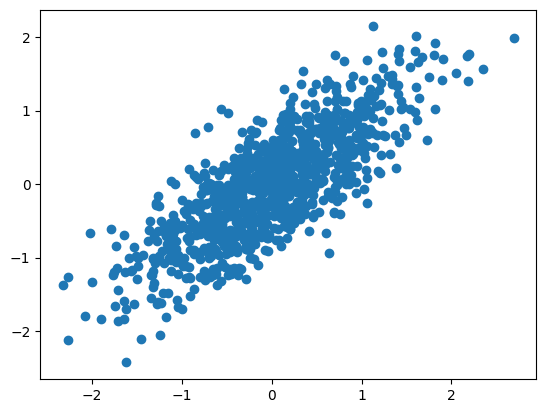

In [ ]:
# Create a matrix with columns x and y
xy = np.concatenate(([x] , [y]), axis=0).T 

# Transform the data using the rotation matrix. It correlates the two variables
data = np.dot(xy, rotationMatrix) # Return a nD array

# Print the rotated data
plt.scatter(data[:,0], data[:,1])
plt.show()

Plot the original coordinate system and the PCA-transformed axes together in one figure, overlaying the two principal component directions, PC1 in red and PC2 in blue.

Eigenvectors or principal component: First row must be in the direction of [1, n]
[[ 0.71929678  0.69470292]
 [-0.69470292  0.71929678]]

Eigenvalues or explained variance
[1.01286956 0.1148542 ]


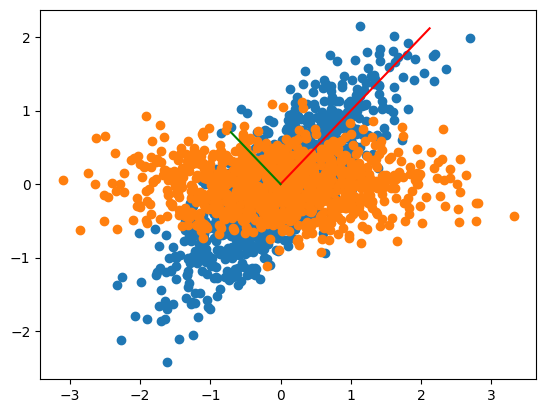

In [19]:
plt.scatter(data[:,0], data[:,1]) # Print the original data in blue

# Apply PCA. In theory, the Eigenvector matrix must be the 
# inverse of the original rotationMatrix. 
pca = PCA(n_components=2)  # Instantiate a PCA. Choose to get 2 output variables

# Create the transformation model for this data. Internally it gets the rotation 
# matrix and the explained variance
pcaTr = pca.fit(data)

# Create an array with the transformed data
dataPCA = pcaTr.transform(data)

print('Eigenvectors or principal component: First row must be in the direction of [1, n]')
print(pcaTr.components_)

print()
print('Eigenvalues or explained variance')
print(pcaTr.explained_variance_)

# Print the rotated data
plt.scatter(dataPCA[:,0], dataPCA[:,1])

# Plot the first component axe. Use the explained variance to scale the vector
plt.plot([0, rotationMatrix[0][0] * std1 * 3], [0, rotationMatrix[0][1] * std1 * 3], color='red')
# Plot the second component axe. Use the explained variance to scale the vector
plt.plot([0, rotationMatrix[1][0] * std2 * 3], [0, rotationMatrix[1][1] * std2 * 3], color='green')

plt.show()

#### Interpreting the plot

- The **rotation matrix** used to synthesize the data maps the original, independent variables $x$ and $y$ into a **correlated** cloud (blue points).

- **PCA** estimates that rotation and **rotates back**: the transformed axes $\mathrm{PC1}$ and $\mathrm{PC2}$ align with the directions of **max** and **min** variance, making the components uncorrelated.

- The **explained variance** (eigenvalues) for this run is
  $$
  [\,1.0094,\; 0.1125\,],
  $$
  which is close to
  $$
  [\,1,\; 0.333^2\,] \;=\; [\,\mathrm{std}_1^2,\; \mathrm{std}_2^2\,].
  $$
  Thus, $\mathrm{PC1}$ captures essentially all of the spread, while $\mathrm{PC2}$ carries very little.

- If we vary $\sigma_1,\ \sigma_2$ and the rotation angle to observe the same behavior: PCA aligns with the dominant direction and reports variances matching the underlying scales.
